# **Outliers Detection -II**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning/Python codes/Python Libraries Basics/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
592,7.09,27.0,1
438,7.31,7.0,0
1,7.46,38.0,1
717,6.49,21.0,0
813,7.43,52.0,1


The skewness of CGPA is: -0.014529938929314918
The skewness of placement exam marks is: 0.8356419499466834


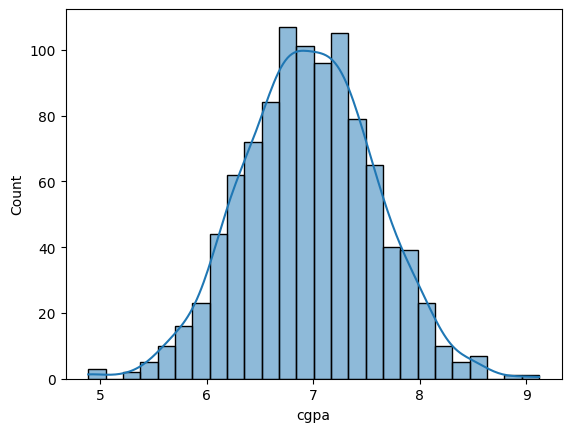

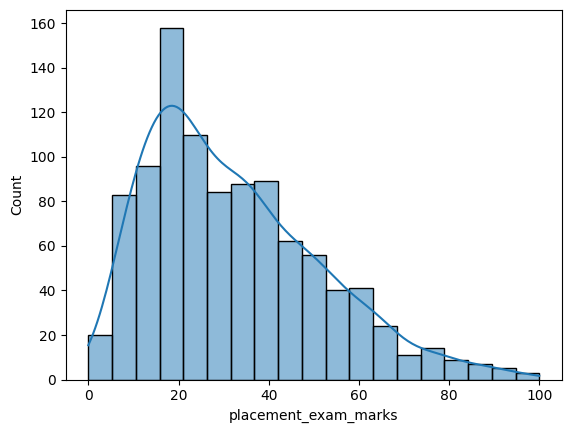

In [4]:
print("The skewness of CGPA is:", df['cgpa'].skew())
print("The skewness of placement exam marks is:", df['placement_exam_marks'].skew())

sns.histplot(df['cgpa'], kde=True)
plt.show()

sns.histplot(df['placement_exam_marks'], kde=True)
plt.show()

In [5]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


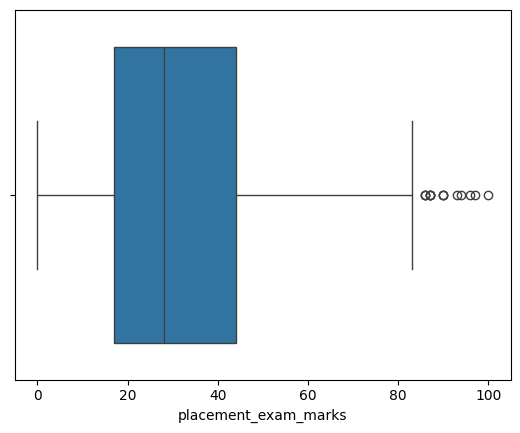

In [8]:
sns.boxplot(df['placement_exam_marks'], orient='h')
plt.show()

In [10]:
#finding the values
p25=df['placement_exam_marks'].quantile(0.25)
p75=df['placement_exam_marks'].quantile(0.75)
iqr=p75-p25
print(iqr)

27.0


In [11]:
upper_bound=p75+(1.5*iqr)
lower_bound=p25-(1.5*iqr)
print(upper_bound)
print(lower_bound)

84.5
-23.5


In [12]:
outlier=df[(df['placement_exam_marks']>upper_bound) | (df['placement_exam_marks']<lower_bound)]
outlier

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# **Trimming**

In [13]:
trim_df=df[(df['placement_exam_marks']<upper_bound) & (df['placement_exam_marks']>lower_bound)]
trim_df


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


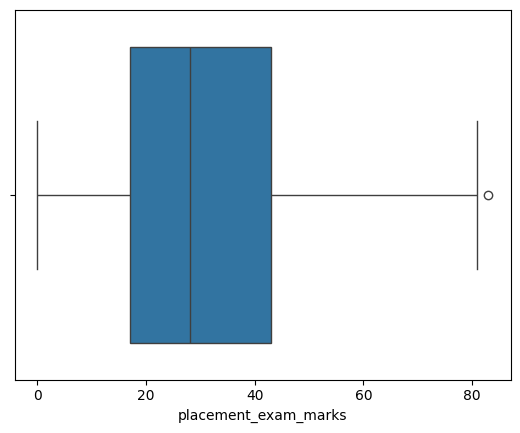

In [14]:
sns.boxplot(trim_df['placement_exam_marks'], orient='h')
plt.show()

# **Capping**

In [16]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_bound,
    upper_bound,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_bound,
        lower_bound,
        new_df_cap['placement_exam_marks']
    )
)

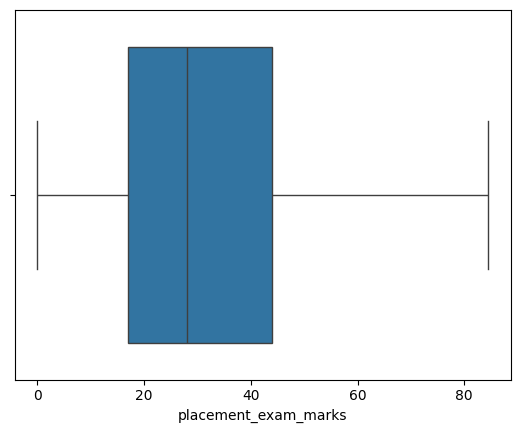

In [19]:
#We cap the outliers
sns.boxplot(new_df_cap['placement_exam_marks'], orient='h')
plt.show()

In [21]:
new_df_cap.sample(5)

,cgpa,placement_exam_marks,placed
170,6.17,37.0,0
510,6.84,34.0,1
234,8.09,36.0,0
537,7.13,9.0,1
732,7.26,55.0,1
